# Elliptic Bitcoin Dataset — EDA & Preprocessing
**Project:** Temporal GNN + XAI for Anti-Money Laundering  
**Dataset:** Elliptic Bitcoin Transaction Dataset (49 time snapshots)  

### Dataset Structure (confirmed)
| File | Header | Columns |
|---|---|---|
| `elliptic_txs_features.csv` | None | 167 cols: col0=tx_id, col1=time_step, col2–166=165 features |
| `elliptic_txs_classes.csv` | Yes (txId, class) | 2 cols |
| `elliptic_txs_edgelist.csv` | Yes (txId1, txId2) | 2 cols |

### This notebook:
1. Mounts Google Drive and sets up project directories
2. Installs dependencies
3. Loads and describes the raw dataset
4. Full exploratory data analysis (EDA)
5. Preprocesses and builds 49 PyG graph snapshots
6. Saves all processed data back to Drive

---
## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# ── Path configuration ──────────────────────────────────────────────────────
BASE_DIR      = '/content/drive/MyDrive/Capstone/AML Code'
RAW_DIR       = os.path.join(BASE_DIR, 'data', 'raw')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
FIGURES_DIR   = os.path.join(BASE_DIR, 'figures')

# Create output directories if they don't exist
for d in [PROCESSED_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# Verify raw files are present
FEATURES_FILE  = os.path.join(RAW_DIR, 'elliptic_txs_features.csv')
CLASSES_FILE   = os.path.join(RAW_DIR, 'elliptic_txs_classes.csv')
EDGELIST_FILE  = os.path.join(RAW_DIR, 'elliptic_txs_edgelist.csv')

for f in [FEATURES_FILE, CLASSES_FILE, EDGELIST_FILE]:
    status = '✓ Found' if os.path.exists(f) else '✗ MISSING'
    print(f'{status}  {f}')

Mounted at /content/drive
✓ Found  /content/drive/MyDrive/Capstone/data/raw/elliptic_txs_features.csv
✓ Found  /content/drive/MyDrive/Capstone/data/raw/elliptic_txs_classes.csv
✓ Found  /content/drive/MyDrive/Capstone/data/raw/elliptic_txs_edgelist.csv


---
## Cell 2 — Install Dependencies

In [ ]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

torch_version = torch.__version__.split('+')[0]
cuda_version  = 'cu121' if torch.cuda.is_available() else 'cpu'

!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html
!pip install -q scikit-learn matplotlib seaborn

print('\nAll dependencies installed.')

PyTorch version : 2.10.0+cpu
CUDA available  : False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.1 MB/s eta 0:00:00

All dependencies installed.


---
## Cell 3 — Imports & Global Config

In [ ]:
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
from torch_geometric.data import Data

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED  = 42
NUM_FEATURES = 165          # Confirmed: 167 cols - tx_id - time_step = 165
TRAIN_END    = 34
VAL_START    = 35
VAL_END      = 36
TEST_START   = 37
TEST_END     = 49
SHUTDOWN_STEP = 43          # Dark market shutdown — documented drift point

feature_cols = [f'feat_{i}' for i in range(NUM_FEATURES)]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Feature columns  : {NUM_FEATURES}  (feat_0 to feat_{NUM_FEATURES-1})')
print(f'Train snapshots  : T1  – T{TRAIN_END}')
print(f'Val snapshots    : T{VAL_START} – T{VAL_END}')
print(f'Test snapshots   : T{TEST_START} – T{TEST_END}')
print('Imports complete.')

Feature columns  : 165  (feat_0 to feat_164)
Train snapshots  : T1  – T34
Val snapshots    : T35 – T36
Test snapshots   : T37 – T49
Imports complete.


---
## Cell 4 — Load Raw Data
**Important:**
- `features.csv` has **no header** — assign manually
- `classes.csv` and `edgelist.csv` **have headers** — read normally

In [ ]:
# ── Features ─────────────────────────────────────────────────────────────────
# NO header row. 167 columns:
#   col 0        = tx_id
#   col 1        = time_step
#   col 2 – 166  = 165 features (feat_0 to feat_164)
features_df = pd.read_csv(FEATURES_FILE, header=None)
features_df.columns = ['tx_id', 'time_step'] + feature_cols

# ── Classes ──────────────────────────────────────────────────────────────────
# HAS header row: txId, class
classes_df = pd.read_csv(CLASSES_FILE, header=0)
classes_df.columns = ['tx_id', 'label']

# ── Edgelist ─────────────────────────────────────────────────────────────────
# HAS header row: txId1, txId2
edges_df = pd.read_csv(EDGELIST_FILE, header=0)
edges_df.columns = ['src', 'dst']

print('Raw data loaded.')
print(f'  features_df : {features_df.shape}  (expected: ~203K rows × 167 cols)')
print(f'  classes_df  : {classes_df.shape}')
print(f'  edges_df    : {edges_df.shape}')
print()
print('features_df columns check:')
print(f'  First 4 cols : {list(features_df.columns[:4])}')
print(f'  Last  4 cols : {list(features_df.columns[-4:])}')
print(f'  Total cols   : {len(features_df.columns)}  (expected: 167)')
print()
print('First 2 rows of features_df:')
display(features_df[['tx_id', 'time_step', 'feat_0', 'feat_1', 'feat_2']].head(2))

Raw data loaded.
  features_df : (203769, 167)  (expected: ~203K rows × 167 cols)
  classes_df  : (203769, 2)
  edges_df    : (234355, 2)

features_df columns check:
  First 4 cols : ['tx_id', 'time_step', 'feat_0', 'feat_1']
  Last  4 cols : ['feat_161', 'feat_162', 'feat_163', 'feat_164']
  Total cols   : 167  (expected: 167)

First 2 rows of features_df:


,tx_id,time_step,feat_0,feat_1,feat_2
0,230425980,1,-0.171469,-0.184668,-1.201369
1,5530458,1,-0.171484,-0.184668,-1.201369


---
## Cell 5 — Dataset Overview

In [ ]:
print('=' * 55)
print('  ELLIPTIC BITCOIN DATASET — OVERVIEW')
print('=' * 55)

n_tx        = features_df['tx_id'].nunique()
n_edges     = len(edges_df)
n_timesteps = features_df['time_step'].nunique()

label_counts = classes_df['label'].value_counts()
# Correct label counts
n_illicit = int(label_counts.get('1', label_counts.get(1, 0)))  # class 1 = illicit
n_licit   = int(label_counts.get('2', label_counts.get(2, 0)))  # class 2 = licit
n_unknown = int(label_counts.get('unknown', 0))
n_labelled = n_licit + n_illicit

print(f'  Total transactions     : {n_tx:,}')
print(f'  Total edges            : {n_edges:,}')
print(f'  Time snapshots         : {n_timesteps}  (T1 – T49)')
print(f'  Features per node      : {NUM_FEATURES}  (feat_0 to feat_{NUM_FEATURES-1})')
print(f'    Local features       : feat_0  to feat_93   (94 features)')
print(f'    Aggregated features  : feat_94 to feat_164  (71 features)')
print()
print(f'  Label breakdown')
print(f'    Licit   (class 2)    : {n_licit:,}')
print(f'    Illicit (class 1)    : {n_illicit:,}')
print(f'    Unknown (dropped)    : {n_unknown:,}')
print()
print(f'  Illicit rate (labelled): {n_illicit/n_labelled*100:.2f}%')
print(f'  Class imbalance        : 1 : {n_licit/n_illicit:.1f}  (illicit : licit)')
print()
print(f'  Temporal split')
print(f'    Train : T1  – T{TRAIN_END}  ({TRAIN_END} snapshots)')
print(f'    Val   : T{VAL_START} – T{VAL_END}   ({VAL_END - VAL_START + 1} snapshots)')
print(f'    Test  : T{TEST_START} – T{TEST_END}  ({TEST_END - TEST_START + 1} snapshots)')
print('=' * 55)
print()
print('NOTE: Features are fully anonymized (no semantic names).')
print('      Explainability tracks feature INDEX importance, not semantic meaning.')

  ELLIPTIC BITCOIN DATASET — OVERVIEW
  Total transactions     : 203,769
  Total edges            : 234,355
  Time snapshots         : 49  (T1 – T49)
  Features per node      : 165  (feat_0 to feat_164)
    Local features       : feat_0  to feat_93   (94 features)
    Aggregated features  : feat_94 to feat_164  (71 features)

  Label breakdown
    Licit   (class 2)    : 42,019
    Illicit (class 1)    : 4,545
    Unknown (dropped)    : 157,205

  Illicit rate (labelled): 9.76%
  Class imbalance        : 1 : 9.2  (illicit : licit)

  Temporal split
    Train : T1  – T34  (34 snapshots)
    Val   : T35 – T36   (2 snapshots)
    Test  : T37 – T49  (13 snapshots)

NOTE: Features are fully anonymized (no semantic names).
      Explainability tracks feature INDEX importance, not semantic meaning.


---
## Cell 6 — Merge & Filter Labelled Transactions

In [ ]:
# Merge features with labels
df = features_df.merge(classes_df, on='tx_id', how='left')

# CORRECTED label remapping
df_labelled = df[df['label'].isin(['1', '2', 1, 2])].copy()
df_unknown  = df[df['label'] == 'unknown'].copy()

# Remap: 2 (licit) → 0,  1 (illicit) → 1
df_labelled['label'] = df_labelled['label'].astype(int).map({1: 1, 2: 0})

print(f'Total transactions : {len(df):,}')
print(f'Labelled           : {len(df_labelled):,}  → used for all modelling')
print(f'Unknown            : {len(df_unknown):,} → permanently excluded')
print()
vc = df_labelled['label'].value_counts().sort_index()
print('Label distribution in labelled set (after remapping):')
print(f'  0 (licit)   : {vc[0]:,}  ({vc[0]/len(df_labelled)*100:.1f}%)')
print(f'  1 (illicit) : {vc[1]:,}  ({vc[1]/len(df_labelled)*100:.1f}%)')
print(f'  Imbalance ratio : 1 : {vc[0]/vc[1]:.1f}')

Total transactions : 203,769
Labelled           : 46,564  → used for all modelling
Unknown            : 157,205 → permanently excluded

Label distribution in labelled set (after remapping):
  0 (licit)   : 42,019  (90.2%)
  1 (illicit) : 4,545  (9.8%)
  Imbalance ratio : 1 : 9.2


---
## Cell 7 — EDA: Transactions & Illicit Rate Per Snapshot

Per-snapshot summary (sample rows):


' time_step  total_nodes  illicit_count  licit_count  illicit_rate  edge_count\n         1         2147             17         2130      0.791803        1924\n        10          972             18          954      1.851852         538\n        20          900            260          640     28.888889         613\n        30          524             83          441     15.839695         372\n        34          515             37          478      7.184466         427\n        35         1341            182         1159     13.571961        1002\n        36         1708             33         1675      1.932084        1148\n        37          498             40          458      8.032129         423\n        49          476             56          420     11.764706         415'

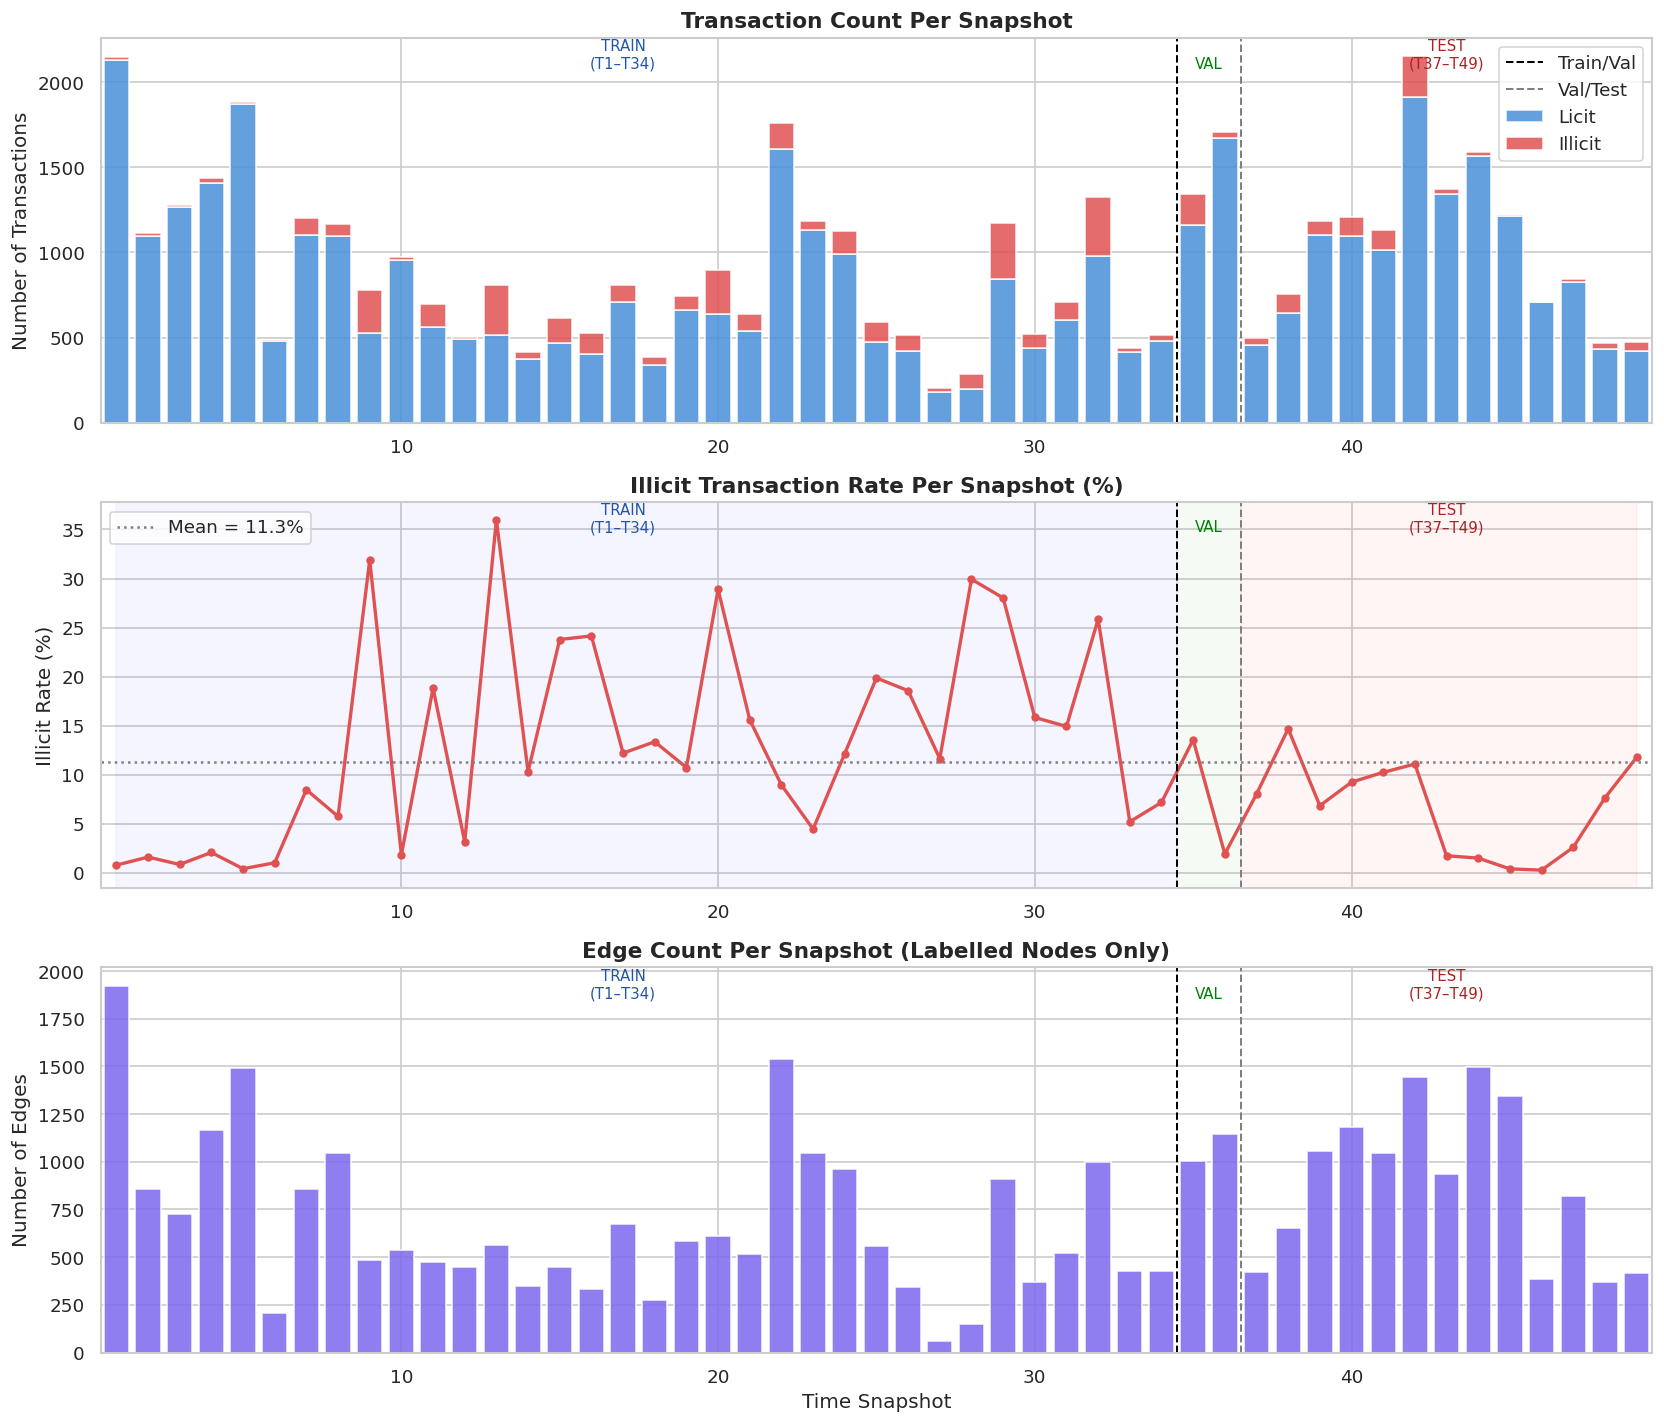

Saved → figures/01_snapshot_overview.png


In [ ]:
# Per-snapshot statistics
snap_stats = df_labelled.groupby('time_step').agg(
    total_nodes   = ('tx_id', 'count'),
    illicit_count = ('label', 'sum')
).reset_index()
snap_stats['licit_count']  = snap_stats['total_nodes'] - snap_stats['illicit_count']
snap_stats['illicit_rate'] = snap_stats['illicit_count'] / snap_stats['total_nodes'] * 100

# Edge count per snapshot
labelled_ids  = set(df_labelled['tx_id'].values)
edges_lab     = edges_df[edges_df['src'].isin(labelled_ids) & edges_df['dst'].isin(labelled_ids)]
src_ts        = df_labelled.set_index('tx_id')['time_step']
edge_counts = edges_lab['src'].map(src_ts).value_counts().sort_index()
edge_counts.index.name = 'time_step'
snap_stats = snap_stats.merge(
    edge_counts.rename('edge_count').reset_index(),
    on='time_step', how='left'
).fillna(0)
snap_stats['edge_count'] = snap_stats['edge_count'].astype(int)

print('Per-snapshot summary (sample rows):')
display(snap_stats[snap_stats['time_step'].isin([1,10,20,30,34,35,36,37,49])].to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
ts = snap_stats['time_step']

# Panel 1: Stacked node count
axes[0].bar(ts, snap_stats['licit_count'],   label='Licit',   color='#4A90D9', alpha=0.85)
axes[0].bar(ts, snap_stats['illicit_count'], bottom=snap_stats['licit_count'],
            label='Illicit', color='#E05252', alpha=0.85)
axes[0].axvline(x=34.5, color='black', linestyle='--', linewidth=1.2, label='Train/Val')
axes[0].axvline(x=36.5, color='gray',  linestyle='--', linewidth=1.2, label='Val/Test')
axes[0].set_title('Transaction Count Per Snapshot', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0.5, 49.5)

# Panel 2: Illicit rate
axes[1].plot(ts, snap_stats['illicit_rate'], color='#E05252', linewidth=2, marker='o', markersize=4)
axes[1].axhline(snap_stats['illicit_rate'].mean(), color='gray', linestyle=':',
                label=f'Mean = {snap_stats["illicit_rate"].mean():.1f}%')
axes[1].axvline(x=34.5, color='black', linestyle='--', linewidth=1.2)
axes[1].axvline(x=36.5, color='gray',  linestyle='--', linewidth=1.2)
axes[1].axvspan(1,    34.5, alpha=0.04, color='blue')
axes[1].axvspan(34.5, 36.5, alpha=0.04, color='green')
axes[1].axvspan(36.5, 49,   alpha=0.04, color='red')
axes[1].set_title('Illicit Transaction Rate Per Snapshot (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Illicit Rate (%)')
axes[1].legend()
axes[1].set_xlim(0.5, 49.5)

# Panel 3: Edge count
axes[2].bar(ts, snap_stats['edge_count'], color='#7B68EE', alpha=0.85)
axes[2].axvline(x=34.5, color='black', linestyle='--', linewidth=1.2)
axes[2].axvline(x=36.5, color='gray',  linestyle='--', linewidth=1.2)
axes[2].set_title('Edge Count Per Snapshot (Labelled Nodes Only)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Edges')
axes[2].set_xlabel('Time Snapshot')
axes[2].set_xlim(0.5, 49.5)

for ax in axes:
    ymax = ax.get_ylim()[1]
    ax.text(17,   ymax*0.92, 'TRAIN\n(T1–T34)',  ha='center', fontsize=9, color='#2255AA')
    ax.text(35.5, ymax*0.92, 'VAL',              ha='center', fontsize=9, color='green')
    ax.text(43,   ymax*0.92, 'TEST\n(T37–T49)', ha='center', fontsize=9, color='#AA2222')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '01_snapshot_overview.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/01_snapshot_overview.png')

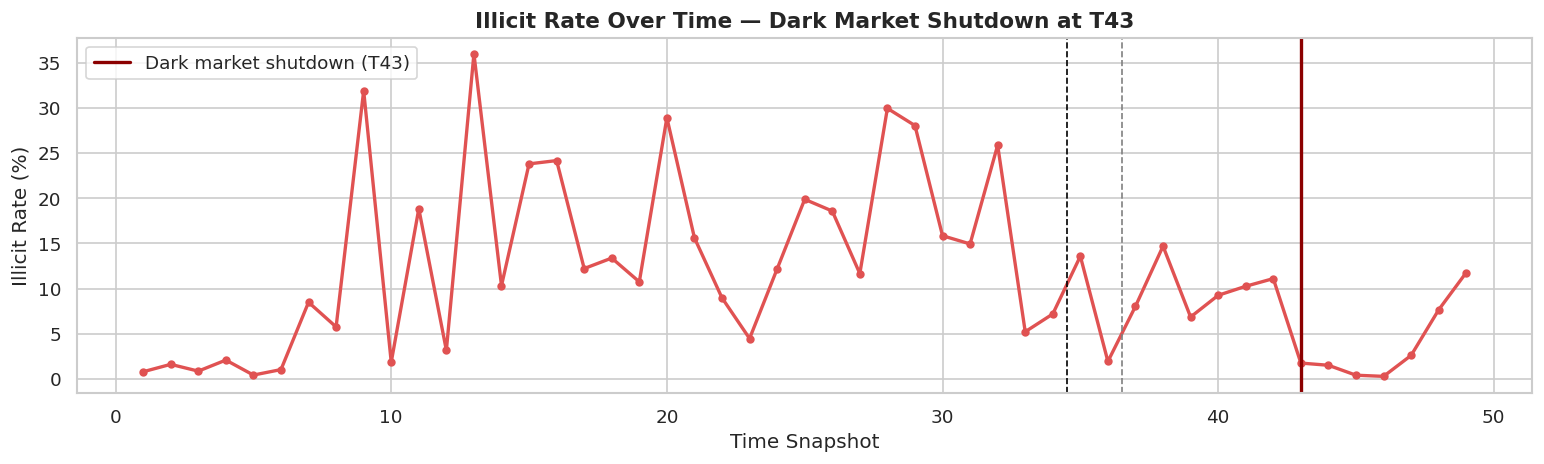

In [ ]:
# Mark the dark market shutdown event

# Plot accuracy over snapshots with T43 marked
# This becomes Figure 1 in the paper — the motivating finding
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(snap_stats['time_step'], snap_stats['illicit_rate'],
        color='#E05252', linewidth=2, marker='o', markersize=4)
ax.axvline(x=SHUTDOWN_STEP, color='darkred', linestyle='-', linewidth=2,
           label=f'Dark market shutdown (T{SHUTDOWN_STEP})')
ax.axvline(x=34.5, color='black', linestyle='--', linewidth=1)
ax.axvline(x=36.5, color='gray',  linestyle='--', linewidth=1)
ax.set_title('Illicit Rate Over Time — Dark Market Shutdown at T43',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Snapshot')
ax.set_ylabel('Illicit Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_shutdown_event.png'), bbox_inches='tight')
plt.show()

---
## Cell 8 — EDA: Feature Distributions (Licit vs Illicit)

Top 10 features with largest mean difference (illicit vs licit):
Feature        Licit Mean   Illicit Mean   Abs Diff Direction
-----------------------------------------------------------------
feat_52            0.9950        -0.2680     1.2630   ↓ illicit lower
feat_54            0.8309        -0.2518     1.0828   ↓ illicit lower
feat_89            0.4913        -0.5322     1.0235   ↓ illicit lower
feat_88            0.4979        -0.5021     1.0001   ↓ illicit lower
feat_53            0.7631        -0.1391     0.9022   ↓ illicit lower
feat_51            0.6301        -0.2235     0.8536   ↓ illicit lower
feat_90            0.4365        -0.3771     0.8135   ↓ illicit lower
feat_58            0.5813        -0.1721     0.7534   ↓ illicit lower
feat_64            0.5812        -0.1721     0.7533   ↓ illicit lower
feat_59            0.5448        -0.1624     0.7071   ↓ illicit lower


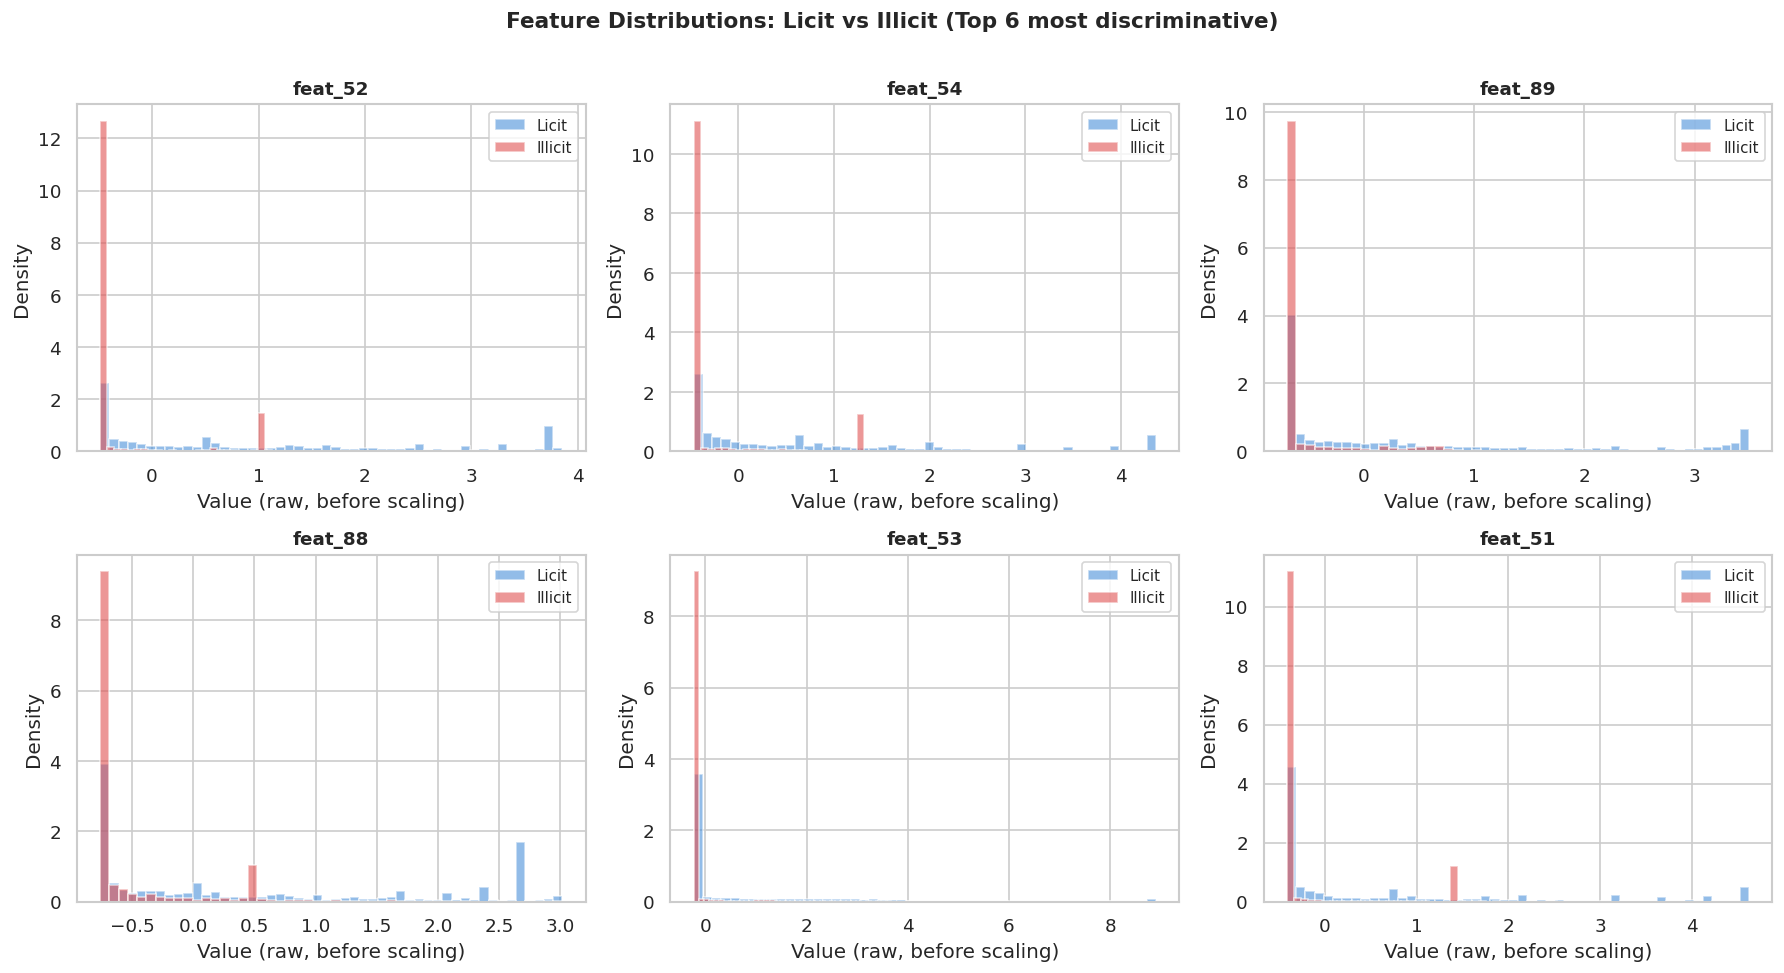

Saved → figures/02_feature_distributions.png


In [ ]:
licit_df   = df_labelled[df_labelled['label'] == 0][feature_cols]
illicit_df = df_labelled[df_labelled['label'] == 1][feature_cols]

# Top 10 features by mean absolute difference
mean_diff = (illicit_df.mean() - licit_df.mean()).abs().sort_values(ascending=False)
top10     = mean_diff.head(10)

print('Top 10 features with largest mean difference (illicit vs licit):')
print(f'{"Feature":<12} {"Licit Mean":>12} {"Illicit Mean":>14} {"Abs Diff":>10} {"Direction"}')
print('-' * 65)
for feat, diff in top10.items():
    l_mean = licit_df[feat].mean()
    i_mean = illicit_df[feat].mean()
    direction = '↑ illicit higher' if i_mean > l_mean else '↓ illicit lower'
    print(f'{feat:<12} {l_mean:>12.4f} {i_mean:>14.4f} {diff:>10.4f}   {direction}')

# ── Plot top 6 ────────────────────────────────────────────────────────────────
top6 = top10.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top6):
    low, high = df_labelled[feat].quantile(0.01), df_labelled[feat].quantile(0.99)
    axes[i].hist(licit_df[feat].clip(low, high),   bins=50, alpha=0.6, color='#4A90D9',
                 label='Licit',   density=True)
    axes[i].hist(illicit_df[feat].clip(low, high), bins=50, alpha=0.6, color='#E05252',
                 label='Illicit', density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value (raw, before scaling)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Licit vs Illicit (Top 6 most discriminative)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '02_feature_distributions.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/02_feature_distributions.png')

---
## Cell 9 — EDA: Feature Correlation Heatmap

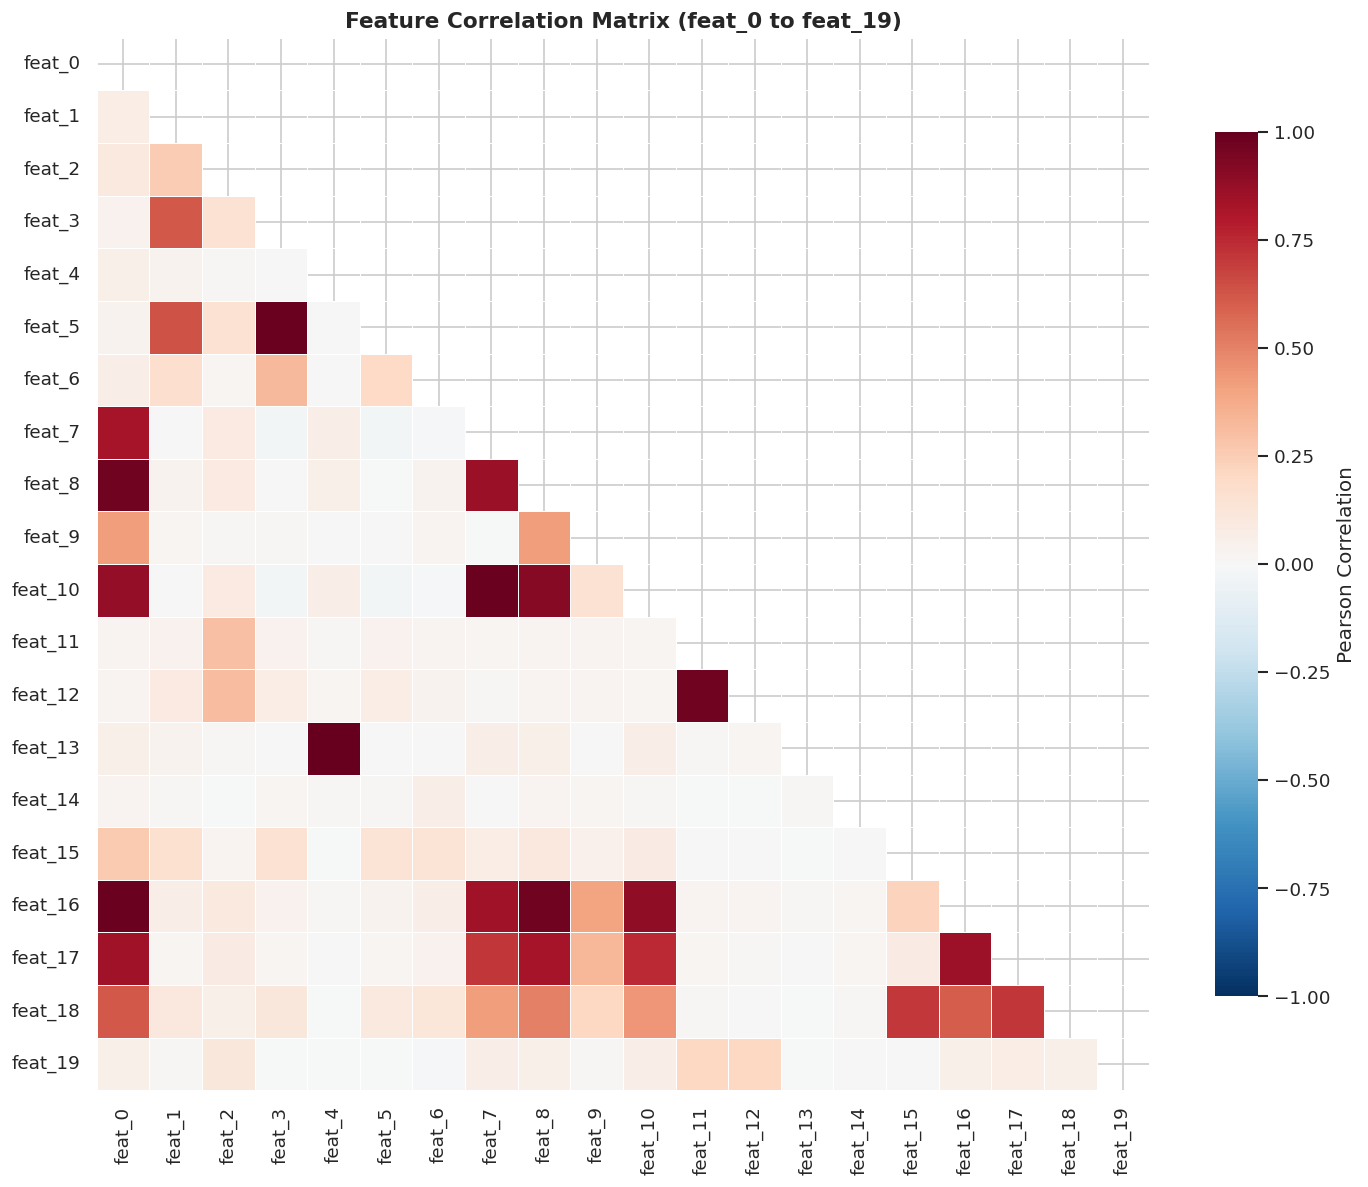

Saved → figures/03_feature_correlation.png

Highly correlated pairs (|r| > 0.9) in first 20 features: 8
  feat_0 ↔ feat_8  :  r = 0.973
  feat_0 ↔ feat_16  :  r = 0.991
  feat_3 ↔ feat_5  :  r = 0.986
  feat_4 ↔ feat_13  :  r = 1.0
  feat_7 ↔ feat_10  :  r = 0.987


In [ ]:
# Correlation heatmap of first 20 local features
sample_feats = feature_cols[:20]
corr = df_labelled[sample_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix (feat_0 to feat_19)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '03_feature_correlation.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/03_feature_correlation.png')

# High-correlation pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(val, 3)))

print(f'\nHighly correlated pairs (|r| > 0.9) in first 20 features: {len(high_corr)}')
for a, b, r in high_corr[:5]:
    print(f'  {a} ↔ {b}  :  r = {r}')

---
## Cell 10 — EDA: PCA Visualisation

PCA variance explained: PC1=14.7%  PC2=6.9%  Total=21.6%


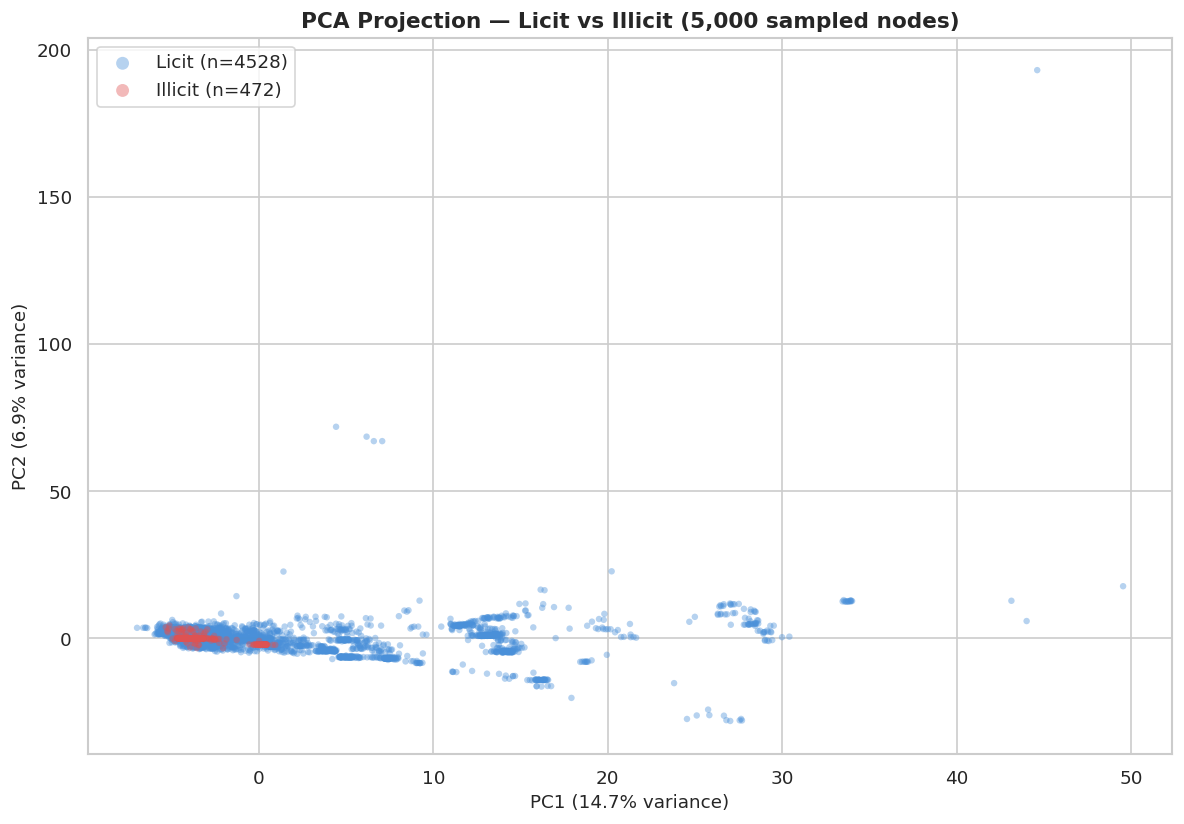

Saved → figures/04_pca_visualization.png


In [ ]:
sample_size = min(5000, len(df_labelled))
sample_df   = df_labelled.sample(sample_size, random_state=RANDOM_SEED)

X_raw = sample_df[feature_cols].values
y_raw = sample_df['label'].values

pca   = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_raw)
var   = pca.explained_variance_ratio_ * 100

print(f'PCA variance explained: PC1={var[0]:.1f}%  PC2={var[1]:.1f}%  Total={sum(var):.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))
for cls, color, label in [(0, '#4A90D9', f'Licit (n={int((y_raw==0).sum())})'),
                           (1, '#E05252', f'Illicit (n={int((y_raw==1).sum())})')  ]:
    mask = y_raw == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
               alpha=0.4, s=15, edgecolors='none')

ax.set_xlabel(f'PC1 ({var[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]:.1f}% variance)', fontsize=11)
ax.set_title('PCA Projection — Licit vs Illicit (5,000 sampled nodes)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '04_pca_visualization.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/04_pca_visualization.png')

---
## Cell 11 — EDA: Degree Distribution

GRAPH STRUCTURE
----------------------------------------
Nodes with out-edges : 34,779
Nodes with in-edges  : 31,408
Out-degree  mean=1.53  median=1  max=472
In-degree   mean=2.74  median=1  max=284


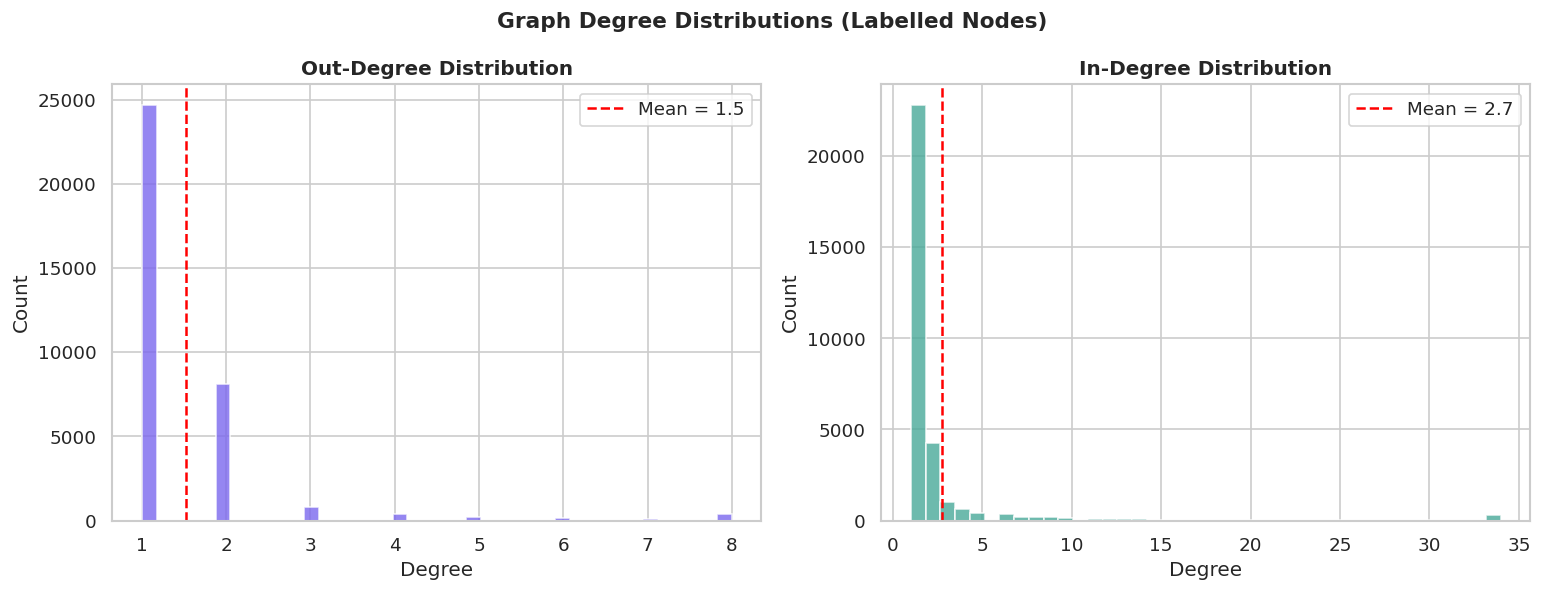

Saved → figures/05_degree_distribution.png


In [ ]:
all_nodes  = set(df_labelled['tx_id'].values)
out_degree = edges_df[edges_df['src'].isin(all_nodes)]['src'].value_counts()
in_degree  = edges_df[edges_df['dst'].isin(all_nodes)]['dst'].value_counts()

print('GRAPH STRUCTURE')
print('-' * 40)
print(f'Nodes with out-edges : {len(out_degree):,}')
print(f'Nodes with in-edges  : {len(in_degree):,}')
print(f'Out-degree  mean={out_degree.mean():.2f}  median={out_degree.median():.0f}  max={out_degree.max()}')
print(f'In-degree   mean={in_degree.mean():.2f}  median={in_degree.median():.0f}  max={in_degree.max()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, deg, title, color in [
    (axes[0], out_degree, 'Out-Degree Distribution', '#7B68EE'),
    (axes[1], in_degree,  'In-Degree Distribution',  '#48A999')
]:
    ax.hist(deg.clip(upper=deg.quantile(0.99)), bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(deg.mean(), color='red', linestyle='--', label=f'Mean = {deg.mean():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Graph Degree Distributions (Labelled Nodes)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '05_degree_distribution.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/05_degree_distribution.png')

---
## Cell 12 — Preprocessing: Fit Scaler on Training Data Only
**Critical:** Scaler must be fit on T1–T34 ONLY. Fitting on the full dataset leaks future distribution information into training.

In [ ]:
train_mask = df_labelled['time_step'] <= TRAIN_END
train_data = df_labelled.loc[train_mask, feature_cols].values

scaler = StandardScaler()
scaler.fit(train_data)

# Apply to full labelled dataset
df_scaled = df_labelled.copy()
df_scaled[feature_cols] = scaler.transform(df_labelled[feature_cols].values)

# Verify
train_scaled = df_scaled.loc[train_mask, feature_cols].values
test_mask    = df_labelled['time_step'] >= TEST_START

print('Scaler fitted and applied.')
print(f'  Training nodes used for fitting : {train_mask.sum():,}')
print(f'  Post-scale mean  (train, feat_0): {train_scaled[:, 0].mean():.6f}  ← should be ~0')
print(f'  Post-scale std   (train, feat_0): {train_scaled[:, 0].std():.6f}   ← should be ~1')
print(f'  Post-scale mean  (test,  feat_0): {df_scaled.loc[test_mask, "feat_0"].mean():.4f}  ← may differ (expected)')
print()
print('NaN check after scaling:', df_scaled[feature_cols].isna().sum().sum(), 'NaN values')

Scaler fitted and applied.
  Training nodes used for fitting : 29,894
  Post-scale mean  (train, feat_0): 0.000000  ← should be ~0
  Post-scale std   (train, feat_0): 1.000000   ← should be ~1
  Post-scale mean  (test,  feat_0): 0.1142  ← may differ (expected)

NaN check after scaling: 0 NaN values


---
## Cell 13 — Build 49 PyG Graph Snapshots

In [ ]:
def get_split(t):
    if t <= TRAIN_END:  return 'train'
    elif t <= VAL_END:  return 'val'
    else:               return 'test'

snapshots   = []
time_steps  = sorted(df_scaled['time_step'].unique())
build_stats = []

print(f'Building {len(time_steps)} snapshots...')
print(f'{"T":>4}  {"Split":>6}  {"Nodes":>7}  {"Edges":>7}  {"Illicit":>7}  {"Illicit%":>9}')
print('-' * 50)

for t in time_steps:
    t_df = df_scaled[df_scaled['time_step'] == t].reset_index(drop=True)

    # Node features (165-dim) and labels
    x = torch.tensor(t_df[feature_cols].values, dtype=torch.float)
    y = torch.tensor(t_df['label'].values,       dtype=torch.long)

    # Local index mapping: tx_id → position in this snapshot
    local_tx_ids    = t_df['tx_id'].values
    local_tx_set    = set(local_tx_ids)
    local_tx_to_idx = {tx_id: idx for idx, tx_id in enumerate(local_tx_ids)}

    # Keep only edges where BOTH endpoints are in this snapshot
    edge_mask = (
        edges_df['src'].isin(local_tx_set) &
        edges_df['dst'].isin(local_tx_set)
    )
    t_edges = edges_df[edge_mask]

    if len(t_edges) > 0:
        src_idx    = t_edges['src'].map(local_tx_to_idx).values
        dst_idx    = t_edges['dst'].map(local_tx_to_idx).values
        edge_index = torch.tensor(np.vstack([src_idx, dst_idx]), dtype=torch.long)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    # Split masks
    split      = get_split(t)
    n          = len(t_df)
    train_mask_t = torch.tensor([split == 'train'] * n, dtype=torch.bool)
    val_mask_t   = torch.tensor([split == 'val']   * n, dtype=torch.bool)
    test_mask_t  = torch.tensor([split == 'test']  * n, dtype=torch.bool)

    data = Data(
        x          = x,
        edge_index = edge_index,
        y          = y,
        train_mask = train_mask_t,
        val_mask   = val_mask_t,
        test_mask  = test_mask_t,
        time_step  = torch.tensor(t,           dtype=torch.long),
        tx_ids     = torch.tensor(local_tx_ids, dtype=torch.long),
        num_nodes  = n,
    )
    snapshots.append(data)

    illicit_count = int(y.sum().item())
    illicit_pct   = illicit_count / n * 100
    build_stats.append({
        'time_step'    : t,
        'split'        : split,
        'nodes'        : n,
        'edges'        : edge_index.shape[1],
        'illicit_count': illicit_count,
        'illicit_pct'  : round(illicit_pct, 2),
    })

    if t in [1, 10, 20, 30, 34, 35, 36, 37, 49]:
        print(f'T{t:>2}  {split:>6}  {n:>7,}  {edge_index.shape[1]:>7,}  '
              f'{illicit_count:>7,}  {illicit_pct:>8.1f}%')

build_df = pd.DataFrame(build_stats)
print()
print(f'All {len(snapshots)} snapshots built successfully.')

Building 49 snapshots...
   T   Split    Nodes    Edges  Illicit   Illicit%
--------------------------------------------------
T 1   train    2,147    1,924       17       0.8%
T10   train      972      538       18       1.9%
T20   train      900      613      260      28.9%
T30   train      524      372       83      15.8%
T34   train      515      427       37       7.2%
T35     val    1,341    1,002      182      13.6%
T36     val    1,708    1,148       33       1.9%
T37    test      498      423       40       8.0%
T49    test      476      415       56      11.8%

All 49 snapshots built successfully.


---
## Cell 14 — Verification: No Leakage & Sanity Checks

In [ ]:
print('VERIFICATION CHECKS')
print('=' * 55)
all_passed = True

# ── Check 1: No leakage ───────────────────────────────────────────────────────
train_ids, test_ids = set(), set()
for snap in snapshots:
    t   = snap.time_step.item()
    ids = set(snap.tx_ids.tolist())
    if t <= TRAIN_END:  train_ids.update(ids)
    elif t >= TEST_START: test_ids.update(ids)

overlap = train_ids & test_ids
status1 = '✓ PASS' if len(overlap) == 0 else f'✗ FAIL ({len(overlap)} overlapping IDs)'
print(f'Check 1 — Data Leakage         : {status1}')
if len(overlap) > 0: all_passed = False

# ── Check 2: Feature dimension ────────────────────────────────────────────────
wrong_dim = [s.time_step.item() for s in snapshots if s.x.shape[1] != NUM_FEATURES]
status2 = f'✓ PASS — all {NUM_FEATURES} features' if len(wrong_dim) == 0 else f'✗ FAIL — snapshots {wrong_dim}'
print(f'Check 2 — Feature Dim = {NUM_FEATURES}    : {status2}')
if len(wrong_dim) > 0: all_passed = False

# ── Check 3: No NaN ───────────────────────────────────────────────────────────
nan_snaps = [s.time_step.item() for s in snapshots if torch.isnan(s.x).any()]
status3 = '✓ PASS' if len(nan_snaps) == 0 else f'✗ FAIL — snapshots {nan_snaps}'
print(f'Check 3 — No NaN values        : {status3}')
if len(nan_snaps) > 0: all_passed = False

# ── Check 4: Edge index bounds ────────────────────────────────────────────────
bad_edges = [s.time_step.item() for s in snapshots
             if s.edge_index.shape[1] > 0 and s.edge_index.max() >= s.num_nodes]
status4 = '✓ PASS' if len(bad_edges) == 0 else f'✗ FAIL — snapshots {bad_edges}'
print(f'Check 4 — Edge index bounds    : {status4}')
if len(bad_edges) > 0: all_passed = False

# ── Check 5: Binary labels ────────────────────────────────────────────────────
bad_labels = [s.time_step.item() for s in snapshots
              if not all(v in [0, 1] for v in s.y.unique().tolist())]
status5 = '✓ PASS' if len(bad_labels) == 0 else f'✗ FAIL — snapshots {bad_labels}'
print(f'Check 5 — Binary labels (0/1)  : {status5}')
if len(bad_labels) > 0: all_passed = False

# ── Check 6: All 49 snapshots ─────────────────────────────────────────────────
status6 = '✓ PASS' if len(snapshots) == 49 else f'✗ FAIL — got {len(snapshots)}'
print(f'Check 6 — 49 snapshots built   : {status6}')
if len(snapshots) != 49: all_passed = False

print()
print('=' * 55)
if all_passed:
    print('OVERALL : ✓ ALL CHECKS PASSED — ready to save')
else:
    print('OVERALL : ✗ FIX ERRORS BEFORE SAVING')

VERIFICATION CHECKS
Check 1 — Data Leakage         : ✓ PASS
Check 2 — Feature Dim = 165    : ✓ PASS — all 165 features
Check 3 — No NaN values        : ✓ PASS
Check 4 — Edge index bounds    : ✓ PASS
Check 5 — Binary labels (0/1)  : ✓ PASS
Check 6 — 49 snapshots built   : ✓ PASS

OVERALL : ✓ ALL CHECKS PASSED — ready to save


---
## Cell 15 — EDA: Snapshot Summary Plot (Post-Build)

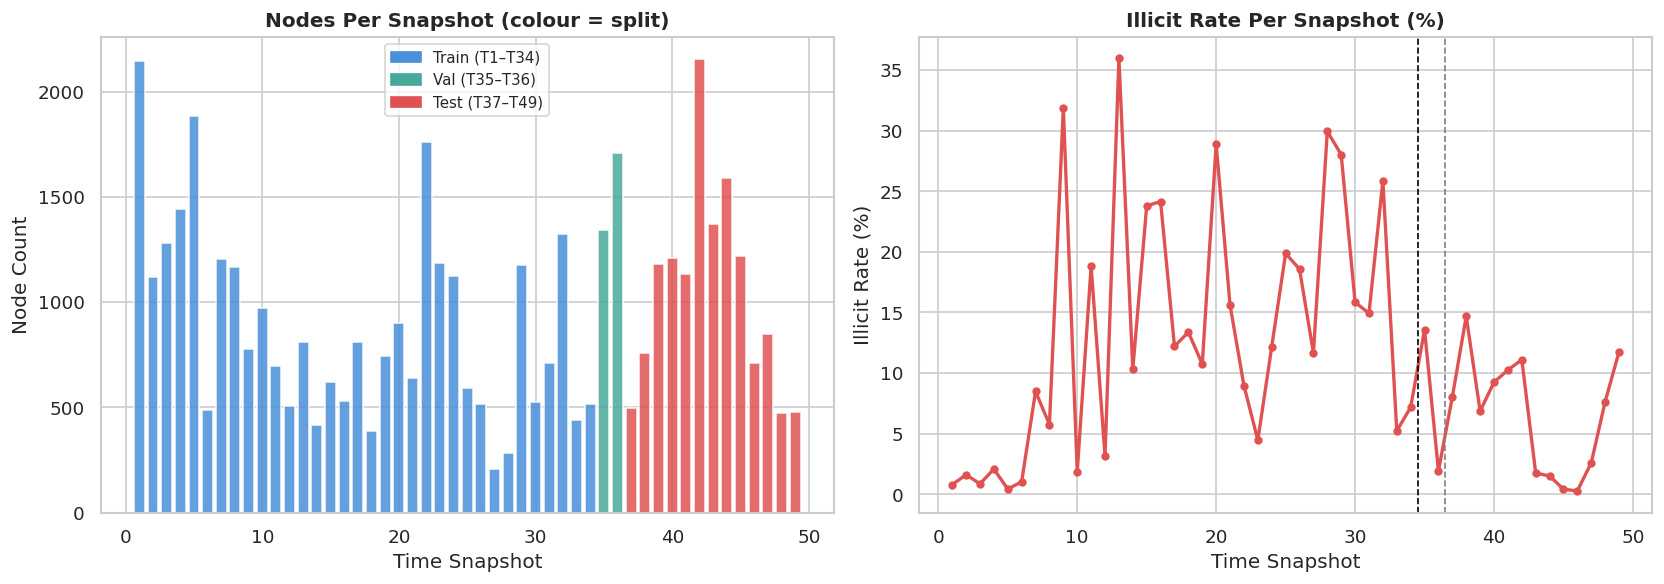

Saved → figures/06_snapshot_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts           = build_df['time_step']
split_colors = build_df['split'].map({'train': '#4A90D9', 'val': '#48A999', 'test': '#E05252'})

# Node count per snapshot
axes[0].bar(ts, build_df['nodes'], color=split_colors, alpha=0.85)
axes[0].set_title('Nodes Per Snapshot (colour = split)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Snapshot')
axes[0].set_ylabel('Node Count')
legend_handles = [
    mpatches.Patch(color='#4A90D9', label=f'Train (T1–T{TRAIN_END})'),
    mpatches.Patch(color='#48A999', label=f'Val (T{VAL_START}–T{VAL_END})'),
    mpatches.Patch(color='#E05252', label=f'Test (T{TEST_START}–T{TEST_END})')
]
axes[0].legend(handles=legend_handles, fontsize=9)

# Illicit rate
axes[1].plot(ts, build_df['illicit_pct'], color='#E05252', linewidth=2, marker='o', markersize=4)
axes[1].axvline(x=34.5, color='black', linestyle='--', linewidth=1)
axes[1].axvline(x=36.5, color='gray',  linestyle='--', linewidth=1)
axes[1].set_title('Illicit Rate Per Snapshot (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Snapshot')
axes[1].set_ylabel('Illicit Rate (%)')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, '06_snapshot_summary.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/06_snapshot_summary.png')

---
## Cell 16 — Save All Processed Data to Drive

In [ ]:
# ── 1. Snapshots ──────────────────────────────────────────────────────────────
snapshots_path = os.path.join(PROCESSED_DIR, 'snapshots.pt')
torch.save(snapshots, snapshots_path)
print(f'✓ snapshots.pt saved       → {snapshots_path}')

# ── 2. Scaler ─────────────────────────────────────────────────────────────────
scaler_path = os.path.join(PROCESSED_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'✓ scaler.pkl saved         → {scaler_path}')

# ── 3. Snapshot stats CSV ─────────────────────────────────────────────────────
stats_path = os.path.join(PROCESSED_DIR, 'snapshot_stats.csv')
build_df.to_csv(stats_path, index=False)
print(f'✓ snapshot_stats.csv saved → {stats_path}')

# ── 4. Metadata JSON ──────────────────────────────────────────────────────────
train_df = build_df[build_df['time_step'] <= TRAIN_END]
meta = {
    'num_snapshots'        : len(snapshots),
    'num_features'         : NUM_FEATURES,
    'feature_cols'         : f'feat_0 to feat_{NUM_FEATURES-1}',
    'local_features'       : 'feat_0 to feat_93 (94 features)',
    'aggregated_features'  : 'feat_94 to feat_164 (71 features)',
    'total_nodes'          : int(build_df['nodes'].sum()),
    'total_edges'          : int(build_df['edges'].sum()),
    'total_illicit'        : int(build_df['illicit_count'].sum()),
    'overall_illicit_pct'  : round(build_df['illicit_count'].sum() / build_df['nodes'].sum() * 100, 3),
    'train_snapshots'      : f'T1–T{TRAIN_END}',
    'val_snapshots'        : f'T{VAL_START}–T{VAL_END}',
    'test_snapshots'       : f'T{TEST_START}–T{TEST_END}',
    'label_mapping'        : {'0': 'licit', '1': 'illicit'},
    'scaler'               : f'StandardScaler fitted on T1–T{TRAIN_END} only',
    'class_imbalance_train': f'1:{round(train_df["nodes"].sum() / train_df["illicit_count"].sum(), 1)} (illicit:licit)',
    'features_anonymized'  : True,
    'note'                 : '165 features confirmed (167 cols - tx_id - time_step)',
}

meta_path = os.path.join(PROCESSED_DIR, 'meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'✓ meta.json saved          → {meta_path}')

print()
print('DATASET SUMMARY')
print('=' * 50)
for k, v in meta.items():
    print(f'  {k:<28} {v}')

✓ snapshots.pt saved       → /content/drive/MyDrive/Capstone/data/processed/snapshots.pt
✓ scaler.pkl saved         → /content/drive/MyDrive/Capstone/data/processed/scaler.pkl
✓ snapshot_stats.csv saved → /content/drive/MyDrive/Capstone/data/processed/snapshot_stats.csv
✓ meta.json saved          → /content/drive/MyDrive/Capstone/data/processed/meta.json

DATASET SUMMARY
  num_snapshots                49
  num_features                 165
  feature_cols                 feat_0 to feat_164
  local_features               feat_0 to feat_93 (94 features)
  aggregated_features          feat_94 to feat_164 (71 features)
  total_nodes                  46564
  total_edges                  36624
  total_illicit                4545
  overall_illicit_pct          9.761
  train_snapshots              T1–T34
  val_snapshots                T35–T36
  test_snapshots               T37–T49
  label_mapping                {'0': 'licit', '1': 'illicit'}
  scaler                       StandardScaler fitted o

---
## Cell 17 — Load Test & Final Verification

In [ ]:
print('LOAD TEST — verifying saved files reload correctly')
print('=' * 55)

loaded_snaps = torch.load(snapshots_path, weights_only=False)
print(f'✓ snapshots.pt  : {len(loaded_snaps)} snapshots')

with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)
print(f'✓ scaler.pkl    : {type(loaded_scaler).__name__}')

with open(meta_path, 'r') as f:
    loaded_meta = json.load(f)
print(f'✓ meta.json     : {len(loaded_meta)} fields')

print()
s1 = loaded_snaps[0]
s49 = loaded_snaps[-1]

print(f'First snapshot  (T{s1.time_step.item()}):')
print(f'  x.shape      : {s1.x.shape}  ← should be (N, {NUM_FEATURES})')
print(f'  edge_index   : {s1.edge_index.shape}')
print(f'  illicit      : {s1.y.sum().item()}')
print(f'  split        : train={s1.train_mask.sum().item()}, val={s1.val_mask.sum().item()}, test={s1.test_mask.sum().item()}')

print()
print(f'Last snapshot   (T{s49.time_step.item()}):')
print(f'  x.shape      : {s49.x.shape}')
print(f'  edge_index   : {s49.edge_index.shape}')
print(f'  illicit      : {s49.y.sum().item()}')
print(f'  split        : train={s49.train_mask.sum().item()}, val={s49.val_mask.sum().item()}, test={s49.test_mask.sum().item()}')

print()
print('=' * 55)
print('PHASE 1 COMPLETE')
print()
print('Next step — Phase 2: Static GCN baseline')
print('Load snapshots with:')
print("  import torch")
print(f"  snapshots = torch.load('{snapshots_path}')")

LOAD TEST — verifying saved files reload correctly
✓ snapshots.pt  : 49 snapshots
✓ scaler.pkl    : StandardScaler
✓ meta.json     : 17 fields

First snapshot  (T1):
  x.shape      : torch.Size([2147, 165])  ← should be (N, 165)
  edge_index   : torch.Size([2, 1924])
  illicit      : 17
  split        : train=2147, val=0, test=0

Last snapshot   (T49):
  x.shape      : torch.Size([476, 165])
  edge_index   : torch.Size([2, 415])
  illicit      : 56
  split        : train=0, val=0, test=476

PHASE 1 COMPLETE

Next step — Phase 2: Static GCN baseline
Load snapshots with:
  import torch
  snapshots = torch.load('/content/drive/MyDrive/Capstone/data/processed/snapshots.pt')


In [ ]:
# Load snapshots if not already in memory
# snapshots = torch.load(snapshots_path, weights_only=False)

# Pick any snapshot to inspect — change this number (1 to 49)
T = 1
snap = snapshots[T - 1]

print(f'SNAPSHOT T{T}')
print('=' * 40)
print(f'Nodes          : {snap.num_nodes:,}')
print(f'Edges          : {snap.edge_index.shape[1]:,}')
print(f'Feature dim    : {snap.x.shape[1]}')
print(f'Licit nodes    : {(snap.y == 0).sum().item():,}')
print(f'Illicit nodes  : {(snap.y == 1).sum().item():,}')
print(f'Illicit rate   : {snap.y.float().mean().item()*100:.1f}%')
print(f'Split          : {"train" if snap.train_mask.any() else "val" if snap.val_mask.any() else "test"}')
print()
print(f'x (first 3 nodes, first 5 features):')
print(snap.x[:3, :5])
print()
print(f'edge_index (first 5 edges):')
print(snap.edge_index[:, :5])
print()
print(f'y (first 10 labels):')
print(snap.y[:10])

SNAPSHOT T1
Nodes          : 2,147
Edges          : 1,924
Feature dim    : 165
Licit nodes    : 2,130
Illicit nodes  : 17
Illicit rate   : 0.8%
Split          : train

x (first 3 nodes, first 5 features):
tensor([[ 0.4406,  3.7010, -0.4018,  7.7393, -0.0511],
        [ 0.1375,  1.1816,  0.1433,  2.6709, -0.0511],
        [-0.1200, -0.2075, -0.9469, -0.1711, -0.0416]])

edge_index (first 5 edges):
tensor([[ 2,  4,  9, 12, 19],
        [ 3,  5, 10, 13, 20]])

y (first 10 labels):
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


T43 subgraph — 200 nodes (24 illicit + 176 licit sampled), 35 edges


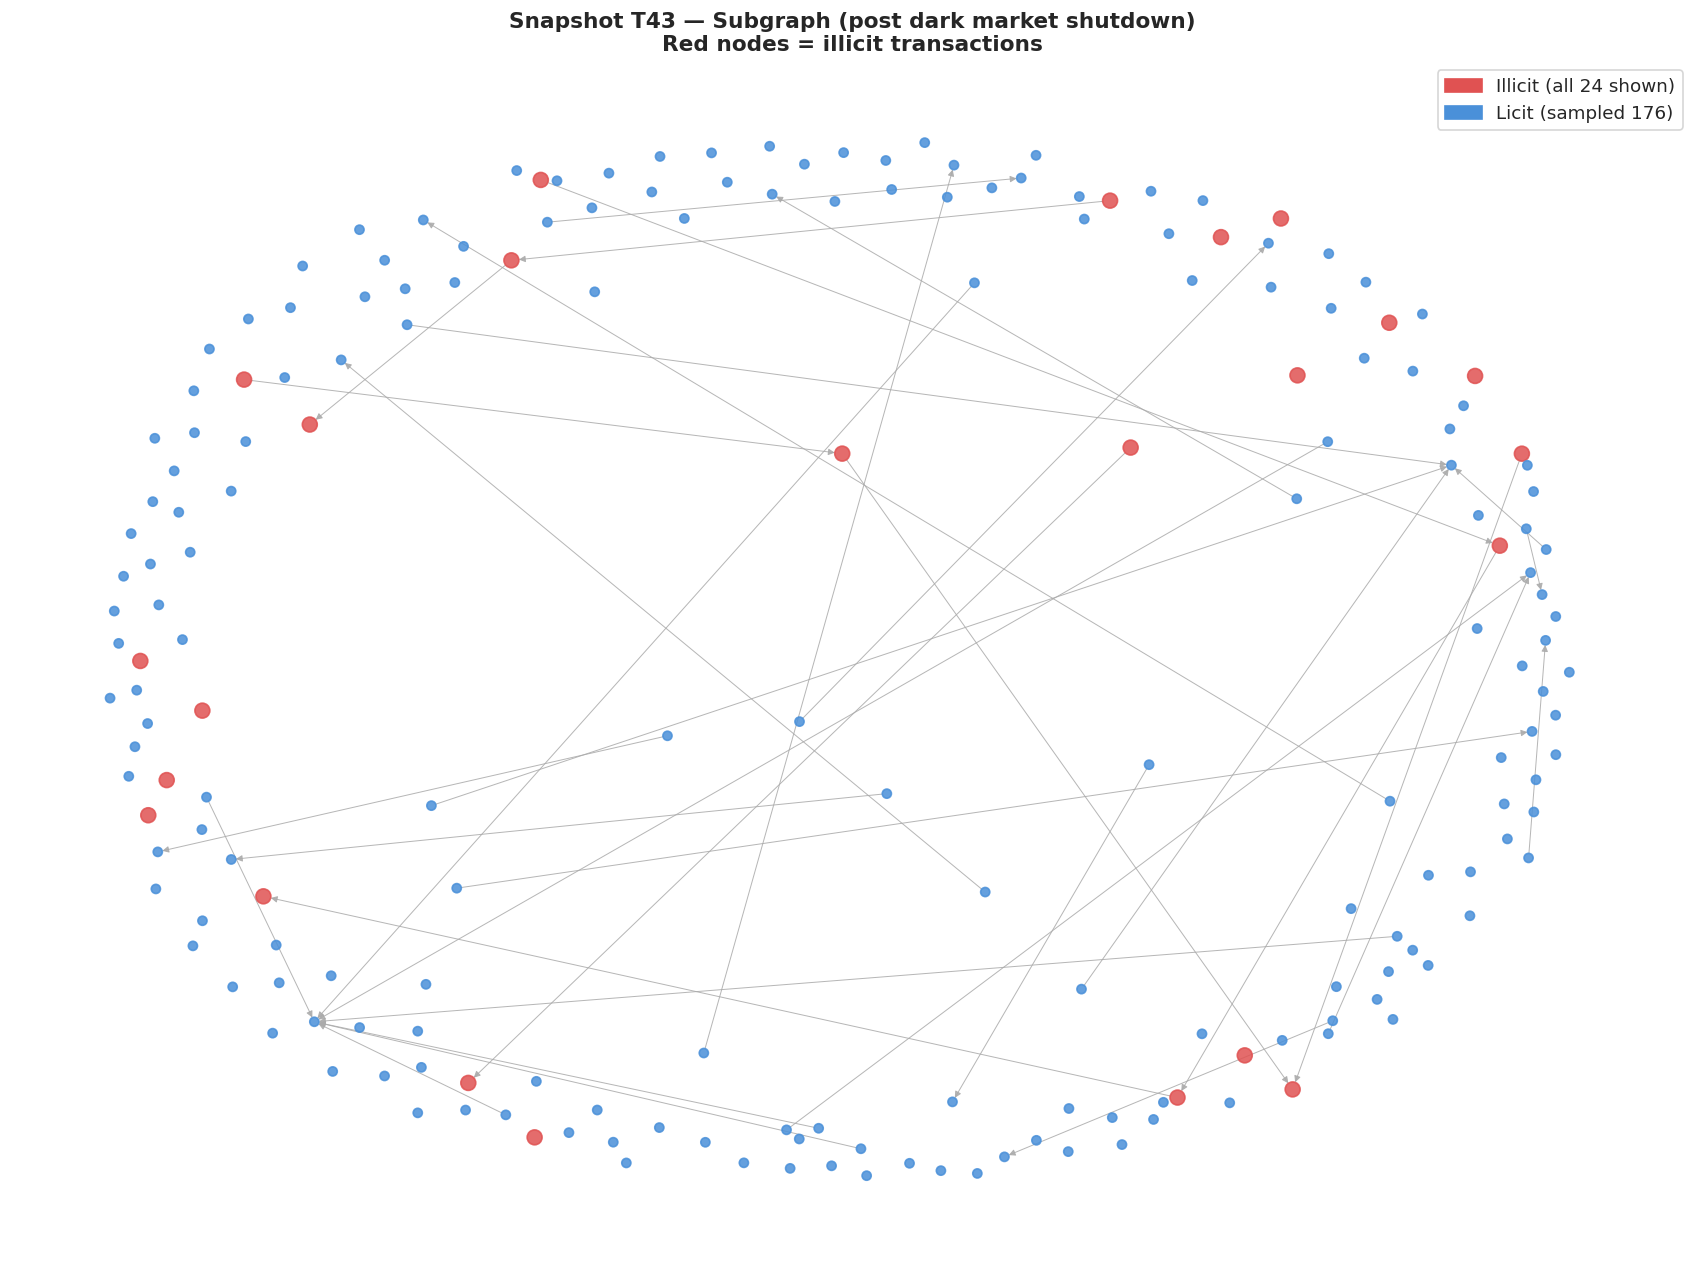

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

T = 43
snap = snapshots[T - 1]

# ── Option 1: Subsample — show only 200 nodes but keep illicit ones ──────────
max_nodes = 200
illicit_idx = (snap.y == 1).nonzero(as_tuple=True)[0].tolist()
licit_idx   = (snap.y == 0).nonzero(as_tuple=True)[0].tolist()

# Keep all illicit + random sample of licit to fill up to max_nodes
n_licit_keep = max(0, max_nodes - len(illicit_idx))
licit_keep   = np.random.choice(licit_idx, min(n_licit_keep, len(licit_idx)), replace=False).tolist()
keep_set     = set(illicit_idx + licit_keep)
keep_list    = sorted(keep_set)
remap        = {old: new for new, old in enumerate(keep_list)}

# Filter edges to only those within the subgraph
ei = snap.edge_index.T.tolist()
sub_edges = [(remap[s], remap[d]) for s, d in ei
             if s in keep_set and d in keep_set]

G = nx.DiGraph()
G.add_nodes_from(range(len(keep_list)))
G.add_edges_from(sub_edges)

colors = ['#E05252' if snap.y[i].item() == 1 else '#4A90D9' for i in keep_list]
sizes  = [80 if snap.y[i].item() == 1 else 30 for i in keep_list]

print(f'T{T} subgraph — {len(keep_list)} nodes '
      f'({len(illicit_idx)} illicit + {len(licit_keep)} licit sampled), '
      f'{len(sub_edges)} edges')

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)
nx.draw(G, pos,
        node_color=colors,
        node_size=sizes,
        edge_color='#AAAAAA',
        alpha=0.85,
        arrows=True,
        arrowsize=8,
        width=0.6)
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#E05252', label=f'Illicit (all {len(illicit_idx)} shown)'),
    Patch(color='#4A90D9', label=f'Licit (sampled {len(licit_keep)})')
], loc='upper right', fontsize=11)
plt.title(f'Snapshot T{T} — Subgraph (post dark market shutdown)\n'
          f'Red nodes = illicit transactions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'snapshot_T{T}_subgraph.png'),
            bbox_inches='tight', dpi=150)
plt.show()